# Breast Cancer Classification – Neural Network vs BDT

In this tutorial we compare two machine learning models:

- A small Neural Network (NN)
- A Boosted Decision Tree (BDT)

We use the Breast Cancer Wisconsin dataset to classify tumors as:

- 0 → Benign
- 1 → Malignant

Since this is a medical application, we will carefully evaluate:

- Training behavior (over/underfitting)
- Prediction distributions
- ROC curves
- Feature importance
- Sensitivity and specificity

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/part0.ipynb)

## 1. Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.ensemble import GradientBoostingClassifier

import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

%matplotlib inline
np.random.seed(42)

## 2. Load and Inspect the Dataset

In [39]:
data = fetch_openml('heart-disease', version=1)

df = data.frame

X = df.drop(columns=['target'])
y = df['target']

print("\nFirst 5 rows of data:")
display(X.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts())


First 5 rows of data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0



Class distribution:
target
1.0    165
0.0    138
Name: count, dtype: int64


## 3. Train/Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 212
Test samples: 91


## 4. Scale Features (for Neural Network)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Build and Train Small Neural Networks (Baseline + Anti-Overfitting)

We’ll start with a baseline model that tends to overfit, then compare three common mitigation techniques: early stopping, L2 regularization, and dropout.

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)

input_dim = X_train_scaled.shape[1]


### 5.1 Baseline (likely to overfit)

We intentionally train longer to make overfitting more visible.

In [55]:
def build_baseline(input_dim):
 model = keras.Sequential([
 layers.Dense(12, activation='relu', input_shape=(input_dim,)),
 layers.Dense(6, activation='relu'),
 layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

baseline = build_baseline(input_dim)
hist_baseline = baseline.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=80,
 batch_size=16,
 verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5.2 Early Stopping

Stops training when validation loss stops improving and restores the best weights.

In [56]:
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_loss',
 patience=10,
 min_delta=1e-4,
 restore_best_weights=True
)

es_model = build_baseline(input_dim)
hist_es = es_model.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=200,
 batch_size=16,
 callbacks=[early_stop],
 verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5.3 L2 Regularization (weight decay)

Adds a penalty on large weights to reduce overfitting.

In [57]:
def build_l2(input_dim, l2=1e-3):
 model = keras.Sequential([
 layers.Dense(12, activation='relu', kernel_regularizer=regularizers.L2(l2), input_shape=(input_dim,)),
 layers.Dense(6, activation='relu', kernel_regularizer=regularizers.L2(l2)),
 layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

l2_model = build_l2(input_dim, l2=1e-3)
hist_l2 = l2_model.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=80,
 batch_size=16,
 verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5.4 Dropout

Randomly drops activations during training to reduce co-adaptation.

In [58]:
def build_dropout(input_dim, rate=0.3):
 model = keras.Sequential([
 layers.Dense(12, activation='relu', input_shape=(input_dim,)),
 layers.Dropout(rate),
 layers.Dense(6, activation='relu'),
 layers.Dropout(rate),
 layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

do_model = build_dropout(input_dim, rate=0.3)
hist_do = do_model.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=80,
 batch_size=16,
 verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Training History (Compare Overfitting)

We plot train vs validation curves for loss and accuracy for all methods.

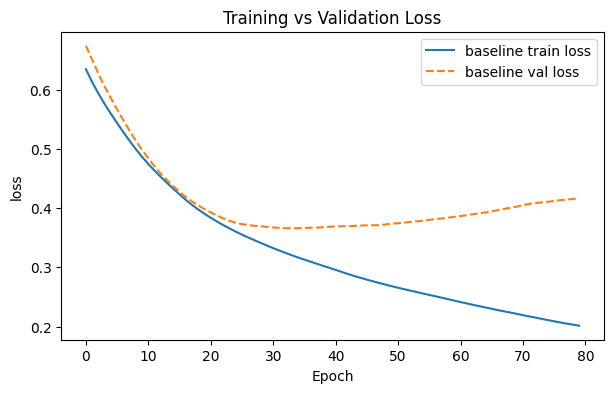

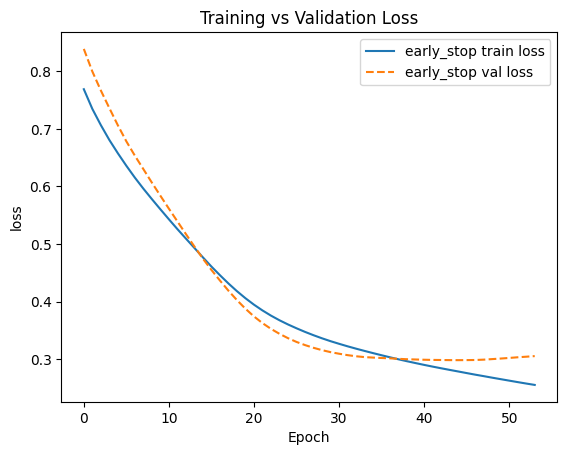

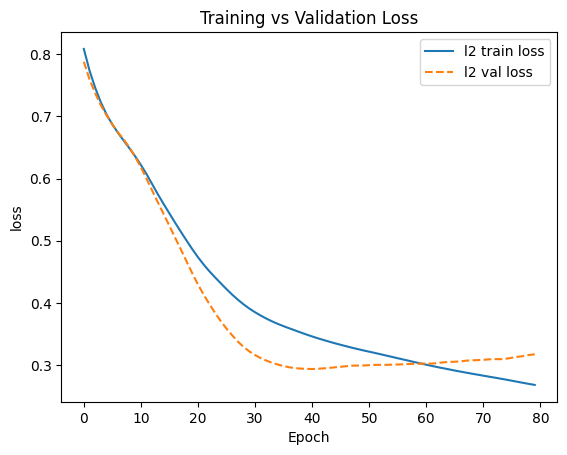

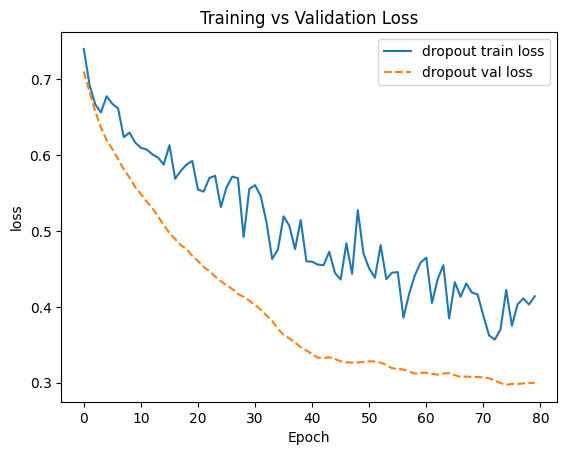

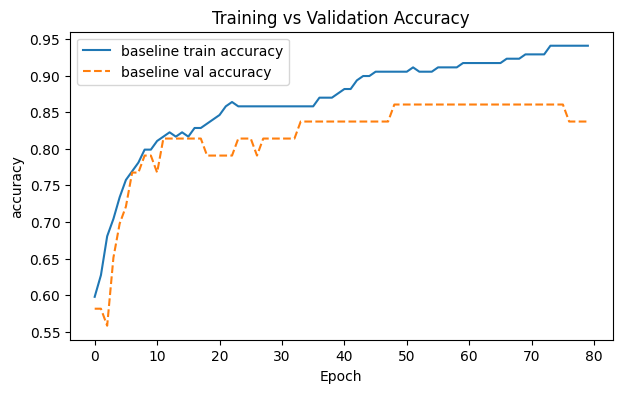

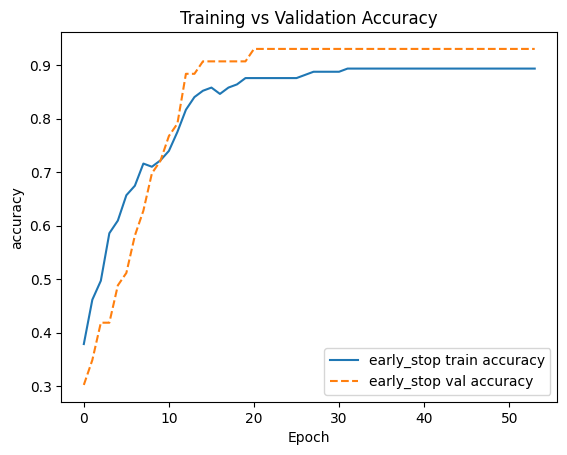

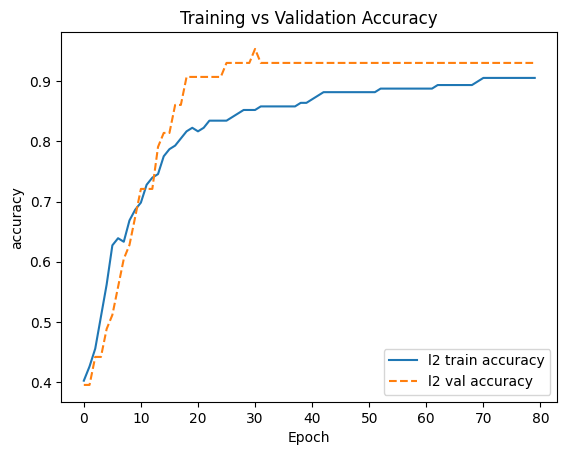

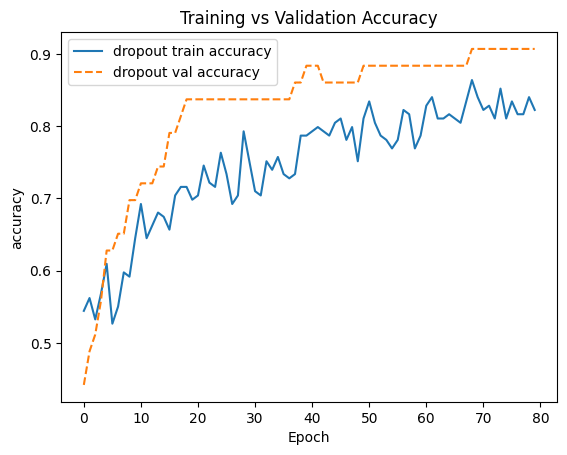

In [59]:
def plot_histories(histories, metric='loss', title=None):
 plt.figure(figsize=(7, 4))
 for name, h in histories.items():
    plt.plot(h.history[metric], label=f"{name} train {metric}")
    plt.plot(h.history[f"val_{metric}"], linestyle='--', label=f"{name} val {metric}")
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.legend()
    plt.show()

histories = {
 'baseline': hist_baseline,
 'early_stop': hist_es,
 'l2': hist_l2,
 'dropout': hist_do,
}

plot_histories(histories, metric='loss', title='Training vs Validation Loss')
plot_histories(histories, metric='accuracy', title='Training vs Validation Accuracy')


## 7. Train a Boosted Decision Tree (BDT)

In [1]:
from xgboost import XGBClassifier

bdt = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.1,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    early_stopping_rounds=30,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# For eval metrics you must provide an eval_set
bdt.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Optional: access the per-boosting-round curves
evals = bdt.evals_result()
# evals["validation_0"]["logloss"], evals["validation_1"]["auc"], etc.

NameError: name 'train_test_split' is not defined

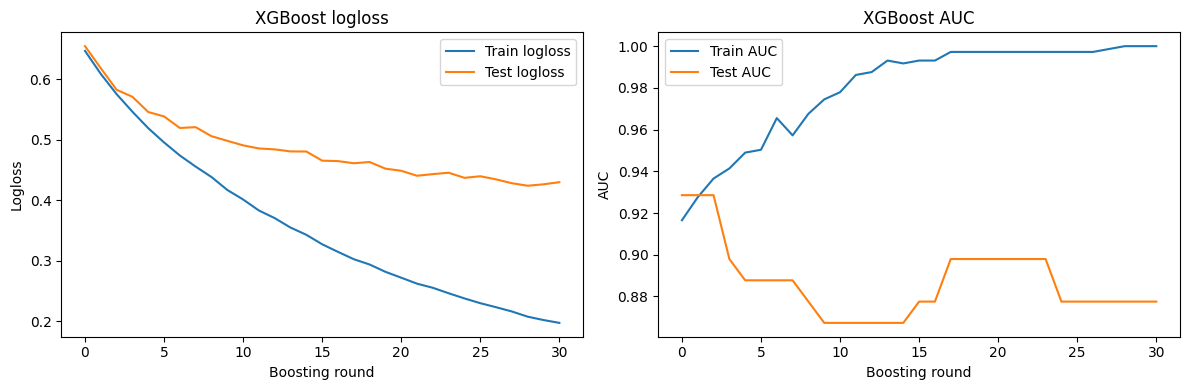

In [82]:
rounds = range(len(evals["validation_0"]["logloss"]))  # number of boosting rounds actually run

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Logloss curve
ax[0].plot(rounds, evals["validation_0"]["logloss"], label="Train logloss")
ax[0].plot(rounds, evals["validation_1"]["logloss"], label="Test logloss")
ax[0].set_xlabel("Boosting round")
ax[0].set_ylabel("Logloss")
ax[0].set_title("XGBoost logloss")
ax[0].legend()

# AUC curve
ax[1].plot(rounds, evals["validation_0"]["auc"], label="Train AUC")
ax[1].plot(rounds, evals["validation_1"]["auc"], label="Test AUC")
ax[1].set_xlabel("Boosting round")
ax[1].set_ylabel("AUC")
ax[1].set_title("XGBoost AUC")
ax[1].legend()

plt.tight_layout()
plt.show()

## 8. Prediction Distributions

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


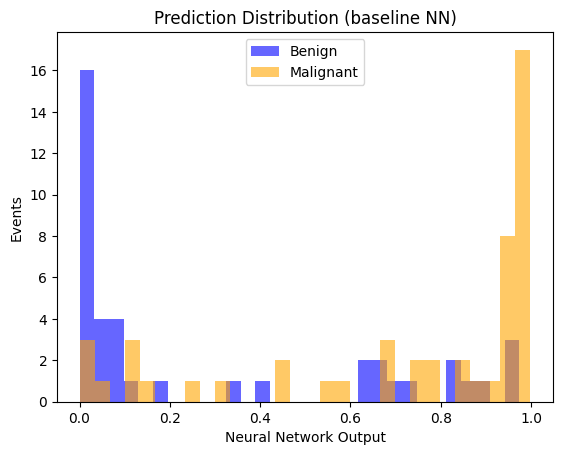

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


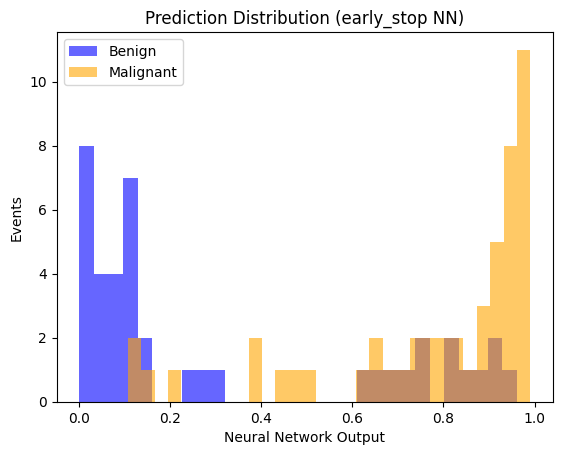

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


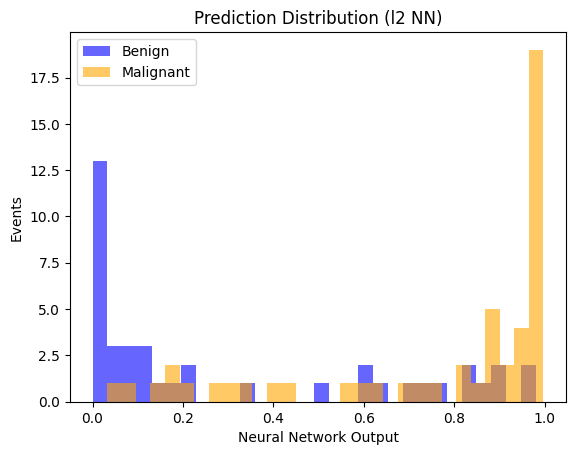

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


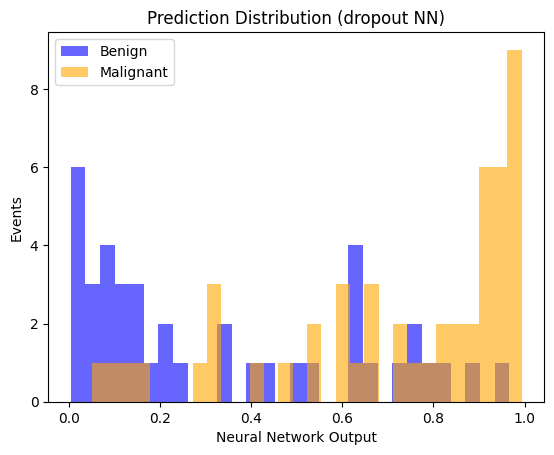

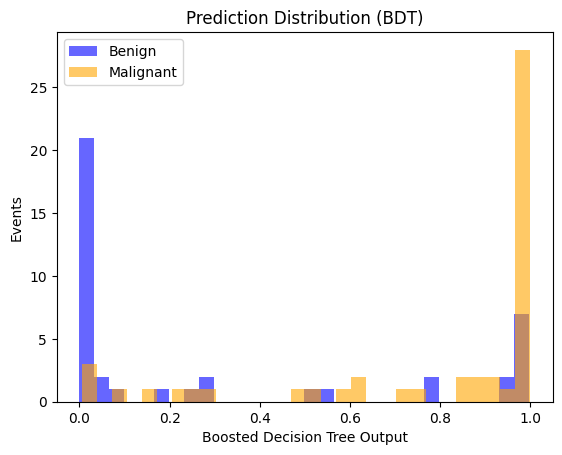

In [70]:
models = [
    ("baseline", baseline),
    ("early_stop", es_model),
    ("l2", l2_model),
    ("dropout", do_model),
]

for name, model in models:
  nn_pred = model.predict(X_test_scaled).ravel()

  plt.figure()
  plt.hist(nn_pred[y_test==0], bins=30, alpha=0.6, label='Benign', color='blue')
  plt.hist(nn_pred[y_test==1], bins=30, alpha=0.6, label='Malignant', color='orange')
  plt.xlabel('Neural Network Output')
  plt.ylabel('Events')
  plt.legend()
  plt.title(f'Prediction Distribution ({name} NN)')
  plt.show()

bdt_pred = bdt.predict_proba(X_test)[:,1]

plt.figure()
plt.hist(bdt_pred[y_test==0], bins=30, alpha=0.6, label='Benign', color='blue')
plt.hist(bdt_pred[y_test==1], bins=30, alpha=0.6, label='Malignant', color='orange')
plt.xlabel('Boosted Decision Tree Output')
plt.ylabel('Events')
plt.legend()
plt.title('Prediction Distribution (BDT)')
plt.show()

## 9. ROC Curve Comparison

In [ ]:
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_pred)
fpr_bdt, tpr_bdt, _ = roc_curve(y_test, bdt_pred)

plt.figure()
plt.plot(fpr_nn, tpr_nn, label=f'NN (AUC={roc_auc_score(y_test, nn_pred):.3f})')
plt.plot(fpr_bdt, tpr_bdt, label=f'BDT (AUC={roc_auc_score(y_test, bdt_pred):.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()

## 10. Feature Importance (BDT)

In [ ]:
importances = pd.Series(bdt.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('BDT Feature Importance')
plt.show()

## 11. Feature Importance (Neural Network via SHAP)

In [ ]:
explainer = shap.Explainer(nn, X_train_scaled)
shap_values = explainer(X_test_scaled[:200])
shap.summary_plot(shap_values, features=X_test.iloc[:200])

## 12. Medical Evaluation: Sensitivity vs Specificity

In medical diagnostics, missing a malignant tumor (false negative) is often worse than a false positive.
We therefore examine the confusion matrix and classification metrics.

In [ ]:
threshold = 0.5
y_pred_binary = (nn_pred > threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))